# Relic abundance calculations for Dark Photon DM

#### Libraries

In [100]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import glob
import csv

## Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})

## Scalar DM case

### Annihilation cross section

First, we consider the annihilation cross section for $\sigma_{\chi \chi \rightarrow f \bar{f}}$. We find after some Feynamnn diagrams and phase space integration that:

$$
\sigma v_{\text{rel}} = \frac{8 \pi}{3} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2} v^2_{\text{rel}} \sum_f K_f,
$$

where the $K_f$ kinematic factor for the fermion $f$ is defined as:
$$
K_f = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\chi^2}} \left( 1 + \frac{1}{2} \frac{m_f^2}{m_\chi^2} \right) \Theta \left( m_\chi - m_f \right).
$$

Thermally averaging using the fact that $\left\langle v^2_{\text{rel}} \right\rangle = \frac{6}{x}$, we get:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle = \frac{16 \pi}{x} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f.
$$

To treat the respective kinematic factors, we must take into account that for quarks, hadrons will be the relevant decay products at low energies. Thus, we will use the $R$ ratio as proxy for decays into hadrons:

$$
R(\sqrt{s}) = \frac{\sigma \left(e^+ e^- \rightarrow \text{hadrons} \right)}{\sigma \left(e^+ e^- \rightarrow \mu^+ \mu^- \right)},
$$

so the sum over kinematic factors becomes:

$$
\sum_f K_f \sim \sum_l K_l (m_\chi) + R(2 m_\chi) K_\mu(m_\chi).
$$

First we implement this cross section. The R ratio is taken from the PDG 2020 data set and interpolated linearly. 

In [101]:
mleptons = np.array([5.11e-4, 0.106, 1.777])  # Masses of leptons in GeV

def Kl(mchi, ml):
    """Phase-space factor for chi chi -> l+ l-, zero below threshold.

    The sqrt and the 1/mchi**2 are only evaluated where mchi > ml, so closed
    channels contribute an exact 0 instead of a nan.
    """
    mchi = np.asarray(mchi, dtype=float)
    opench = mchi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mchi, 1.0)**2, 0.0)
    return np.where(opench, np.sqrt(1 - r2)*(1 + r2/2), 0.0)

def sumKl(mchi):
    total = np.zeros_like(np.asarray(mchi, dtype=float))
    for ml in mleptons:
        total = total + Kl(mchi, ml)
    return total

def Kmu(mchi):
    """Muon phase-space factor, deliberately WITHOUT a threshold cut.

    This is not an open channel in its own right: it is the mu+mu-
    normalisation of the R-ratio, so it must stay un-cut. The kinematic
    condition belongs to R (see RKmu).
    """
    mchi = np.asarray(mchi, dtype=float)
    r2 = mleptons[1]**2/mchi**2
    return np.sqrt(1 - r2)*(1 + r2/2)

### Hadronic R ratio, R = sigma(e+e- -> hadrons)/sigma(e+e- -> mu+mu-),
### from the PDG compilation in data/rratio.dat (1400 points, 0.3-188.7 GeV).

def read_rratio(path="data/rratio.dat"):
    """Read the PDG R-ratio table -> (E_cm, R, dR).

    Fixed-width, per the FORTRAN format documented at the foot of the file
    (f10.5,2x,f10.5,1x,f10.5,2x,f10.5,2x,sp,f10.5,1x,f10.5,...): E(cm) at
    [0:10], R at [35:45], +stat at [47:57], -stat at [58:68].

    Lines whose E(cm) field is blank carry extra systematics for the
    preceding point rather than a new point, and are skipped. They must be
    read by column, not by str.split(): their first non-blank token is a
    signed systematic like '+5.10', which splitting would happily mistake
    for an energy.
    """
    E, R, dR = [], [], []
    with open(path) as f:
        for line in f:
            if line.startswith("*") or not line.strip():
                continue
            try:
                ecm = float(line[0:10])
            except ValueError:
                continue                                  # continuation line
            if ecm <= 0.0:
                continue
            E.append(ecm)
            R.append(float(line[35:45]))
            dR.append(0.5*(abs(float(line[47:57])) + abs(float(line[58:68]))))
    return np.array(E), np.array(R), np.array(dR)

ecm_rratio, Rdata, dRdata = read_rratio()

# 70 energies are quoted by more than one experiment, but interp1d needs a
# strictly increasing x, so repeats are collapsed into a single
# inverse-variance weighted mean (the stat errors are all non-zero).
weights_R = 1.0/dRdata**2
ecm_R, index_R = np.unique(ecm_rratio, return_inverse=True)
R_R = (np.bincount(index_R, weights=weights_R*Rdata)
       / np.bincount(index_R, weights=weights_R))

# Linear in both E and R: the table is dense and full of resonances (rho,
# J/psi, Upsilon, Z), whose peaks a log-log interpolation would distort.
R_interp = interpolate.interp1d(ecm_R, R_R)

def R(sqrts):
    """Hadronic R ratio at sqrt(s), interpolated from the PDG table.

    Below the first tabulated point (0.3 GeV, just above the 2*mpi hadronic
    threshold) there is nothing to produce, so R = 0. That is also what keeps
    RKmu finite: 0.3/2 = 0.15 GeV > m_mu, so wherever R != 0 the un-cut Kmu
    is evaluated above the muon mass. Above the last point (188.7 GeV) the
    value is held flat, which the plots never reach.
    """
    sqrts = np.asarray(sqrts, dtype=float)
    inside = sqrts >= ecm_R[0]
    return np.where(inside, R_interp(np.clip(sqrts, ecm_R[0], ecm_R[-1])), 0.0)

def RKmu(mchi):
    """Hadronic contribution R(2*mchi)*Kmu(mchi).

    The threshold is carried by R, not by Kmu: R vanishes below 2*mpi > m_mu,
    so wherever R != 0 the un-cut Kmu is real. Where R == 0 the product is set
    to an exact 0, avoiding the 0*nan that the bare expression would give
    below the muon mass.
    """
    mchi = np.asarray(mchi, dtype=float)
    Rval = np.asarray(R(2*mchi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mchi, np.inf)   # keeps Kmu real where R == 0
    return np.where(hadopen, Rval*Kmu(safe), 0.0)


def sigmavrel(vare, ma, alpha, alphaD, mchi, x):
    return 16*np.pi/x * (vare**2*alpha*alphaD*mchi**2)/(ma**2 - 4*mchi**2)**2 * (sumKl(mchi) + RKmu(mchi))

### Relic target line calculation

We want to produce the correct relic abundance line as a function of the kinetic mixing $\epsilon$ and the mass of the dark photon $m_{A'}$. We can do this in two different ways:

1. Obtaining some "closed form" via approximations.

2. Solving the Boltzmann equations numerically.

#### Closed form approximations:

We approximate the freeze out temperate $x_f$ using the formula:

$$

x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\chi \right),

$$

where the $m_{\text{pl}}$ is the non reduced Planck mass. We also consider that the correct amount of dark matter is produced for a cross section around:

$$

\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}} \sim 6 \times 10^{-9} \, \text{GeV}^{-2}.

$$

Thus the problem reduces to solving for $\epsilon$ in:

$$

\frac{16 \pi}{x_f} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f = 6 \times 10^{-9} \, \text{GeV}^{-2}.

$$

In [102]:
### Reading the Kling relic line.

kling_relic = np.loadtxt("data/Kling/scalar_DM_Oh2_intermediate_eps_vs_mAprime.txt")

ma_kling = kling_relic[:, 0]      # m_A' in GeV
eps_kling = kling_relic[:, 1]     # kinetic mixing on the relic line

# The file is already sorted in mass, but the plot below assumes it, so check
# rather than trust it.
assert np.all(np.diff(ma_kling) > 0), "m_A' column is not monotonic"

print(f"{len(ma_kling)} points")
print(f"m_A' from {ma_kling.min():.4g} to {ma_kling.max():.4g} GeV")
print(f"eps  from {eps_kling.min():.4g} to {eps_kling.max():.4g}")

106 points
m_A' from 0.001704 to 1.663 GeV
eps  from 2.214e-06 to 0.001284


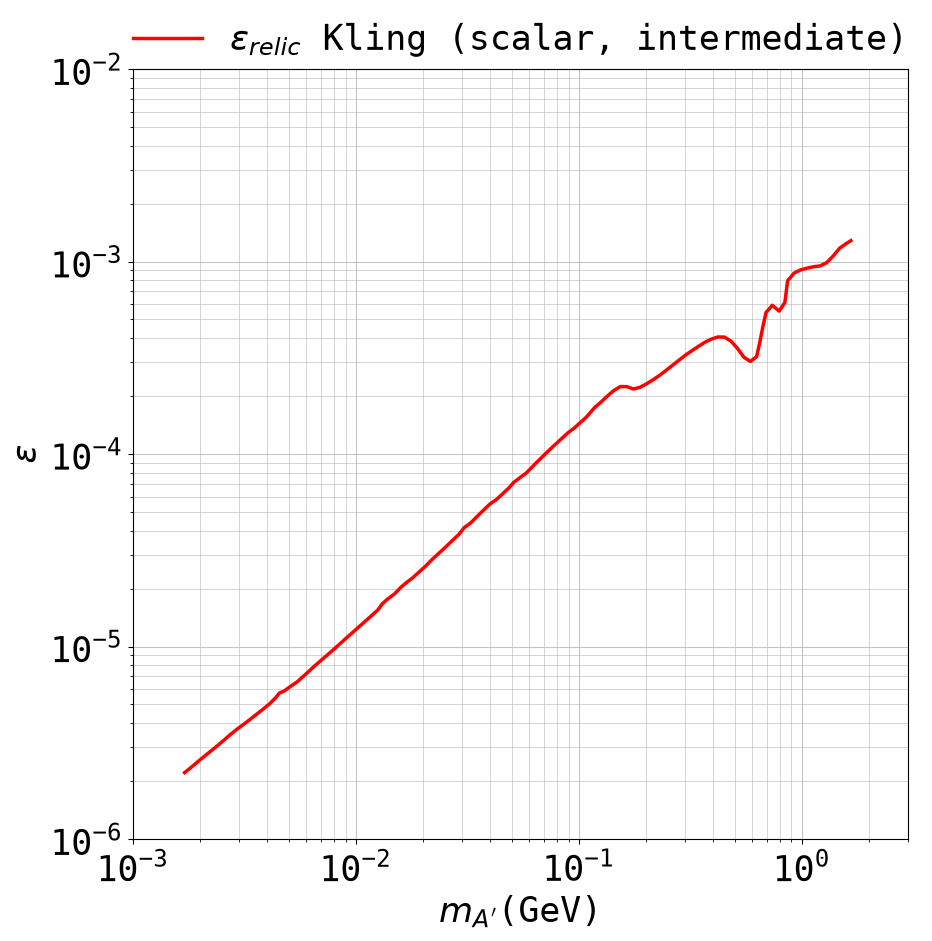

In [103]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Kling (scalar, intermediate)")


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-3
x_max = 3

y_min = 1e-6
y_max = 1e-2

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_kling_0.pdf", bbox_inches='tight')
plt.show()

In [104]:
### Rough calculation for relic aboundance:

Mpl = 2.435323e18 # Reduced planck mass in GeV
mpl = 1.220890e19 # Planck mass in GeV

OmegaDM = 0.265 #Without reduced Hubble constant factor

# Epsilon for the relic line taking xf as a constant and as a function of the thermal production cross section

def eps_approx0(ma, alpha, alphaD, mchi):
    xf = 20
    return np.sqrt(6e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

def eps_approx1(ma, alpha, alphaD, mchi):
    xf = np.log(6e-9*mpl*mchi)
    return np.sqrt(6e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

In [105]:
# Some of the testing parameters:

alpha = 1/137
alphaD = 0.1

ma = np.logspace(-2, 2, 10000)  # Mass range from 0.1 GeV to 1000 GeV

mchi = 0.6*ma

eps_approx_0 = eps_approx0(ma, alpha, alphaD, mchi)

eps_approx_1 = eps_approx1(ma, alpha, alphaD, mchi)

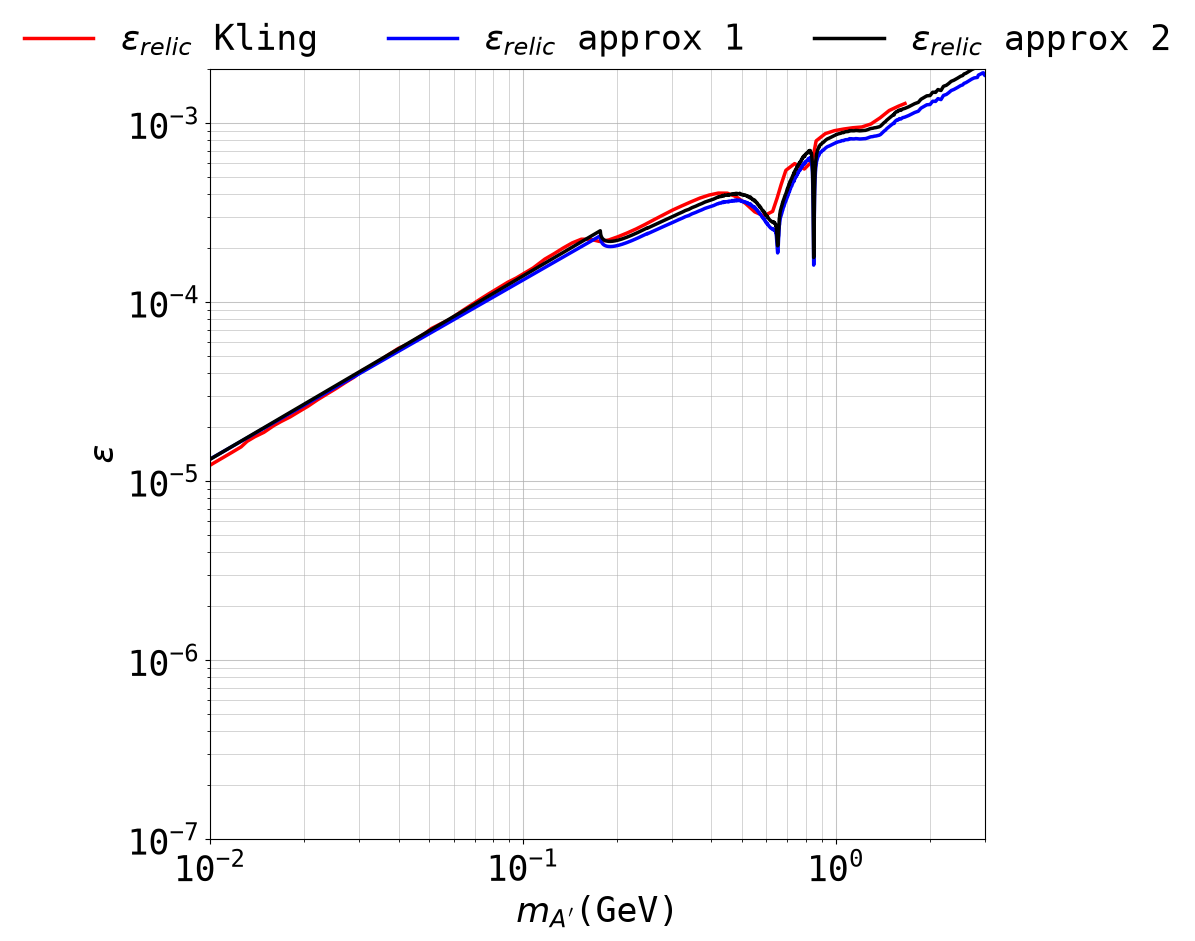

In [106]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")
plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label = r"$\epsilon_{relic}$ approx 1")
plt.plot(ma, eps_approx_1, color = 'black', linewidth = 2.5, label = r"$\epsilon_{relic}$ approx 2")

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

### Better approximations for $x_f$ and $\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}}$

Using the freeze out condition $\Gamma(x_f) = H(x_f)$ it is possible to arrive at the following trascendental equation for $x_f$:

$$
e^{x_f} = \sqrt{\frac{90}{\pi^2}} g_\chi \frac{M_{\text{pl}}}{(2 \pi)^{3/2}} m_\chi \left\langle \sigma v \right\rangle_f x_f^{1/2} (g_*(m_\chi/x_f))^{-1/2}
$$

with

$$
\left\langle \sigma v \right\rangle_f = \frac{2 \pi}{9 \sqrt{10}} \frac{\sqrt{g_*(m_\chi/x_f)}}{g_{*s}(m_\chi/x_f)} g_{*s}(T_0) \frac{T_0^3}{H_0^2 M_{\text{pl}} \Omega_{\text{DM}}} x_f
$$

We can solve for $x_f$ numerically.

First, we need tabulated values for $g_*$ and $g_{*s}$:

In [107]:
### Effective dof from data/effective_dof.csv: g*_e(T) in the energy density
### and g*_s(T) in the entropy density.

# The QCD transition temperature is not settled, so the table lists the
# 150-214 MeV window once per candidate, tagged in the last column by which
# choice(s) the row belongs to ('All' outside that window). Pick one, or
# g*_e is double valued at seven temperatures.
qcd_transition = "214"          # "214", "170" or "150" MeV

dof_table = np.genfromtxt("data/effective_dof.csv", delimiter=',', names=True,
                          dtype=None, encoding='utf-8')

keep_dof = np.array([m == "All" or qcd_transition in m
                     for m in dof_table["transition_temperature_model"]])

T_dof = dof_table["kBT_eV"][keep_dof]*1e-9        # eV -> GeV
gstar_e = dof_table["g_star_e"][keep_dof]
gstar_s = dof_table["g_star_s"][keep_dof]

# Sort on (T, g*_e), not T alone: the transition is a genuine discontinuity,
# tabulated as a '-' and a '+' row at one temperature. g*_e grows with T, so
# breaking the tie on g*_e puts the lower branch first; sorting on T alone
# leaves those two in arbitrary order and can invert the jump. g*_s steps the
# same way across the transition, so this single ordering serves both columns
# and keeps them consistent row by row.
order = np.lexsort((gstar_e, T_dof))
T_dof, gstar_e, gstar_s = T_dof[order], gstar_e[order], gstar_s[order]

# Interpolate against log T: the table is log spaced over nine decades, so
# interpolating against T itself would collapse everything below a GeV.
logT_dof = np.log(T_dof)

# interp1d needs a strictly increasing x, so push each tie up by one float
# step. The jump survives as a near-vertical segment instead of a 0/0.
for i in range(1, len(logT_dof)):
    if logT_dof[i] <= logT_dof[i-1]:
        logT_dof[i] = np.nextafter(logT_dof[i-1], np.inf)

gstar_e_interp = interpolate.interp1d(logT_dof, gstar_e, bounds_error=False,
                                      fill_value=(gstar_e[0], gstar_e[-1]))

gstar_s_interp = interpolate.interp1d(logT_dof, gstar_s, bounds_error=False,
                                      fill_value=(gstar_s[0], gstar_s[-1]))



def gstarfun(T):
    """g*_e at temperature T in GeV, interpolated from the tabulated values.

    Held flat off the ends of the table (10 keV - 10 TeV), where g*_e has
    already plateaued at 3.36 and 106.75 respectively.
    """
    return gstar_e_interp(np.log(np.asarray(T, dtype=float)))


def gstarsfun(T):
    """g*_s at temperature T in GeV, interpolated from the tabulated values.

    Built exactly like gstarfun, off the entropy column. Held flat off the
    ends of the table, where g*_s has plateaued at 3.91 and 106.75. The low
    end sits above g*_e (3.36) because once the neutrinos decouple they stay
    hotter than the photons, and entropy and energy weight that differently.
    """
    return gstar_s_interp(np.log(np.asarray(T, dtype=float)))


In [108]:
gchi = 2

H0 = 1.438e-42 # in GeV
T0 = 2.35e-13 # in GeV

gstarsT0 = gstarsfun(T0)

def sigmavrelic(xf, mchi):
    return 2*3.79*(1+1)*xf**2*2*np.pi**2*mchi*T0**3*gstarsT0/(gstarsfun(mchi/xf)/np.sqrt(gstarfun(mchi/xf))*mpl*mchi*45*3*H0**2*Mpl**2*OmegaDM)


def xfreeze(vare, ma, alpha, alphaD, mchi, xf=20.0):
    """Freeze out x, KT (5.48) with n = 1.

        xf = A - (n + 1/2) ln A
        A  = ln[ (1/2)(n+1) 0.038 gchi mpl mchi sigma_0 / sqrt(g*(T_f)) ]

    sigma_0 is the MODEL cross section: <sigma v> = sigma_0 x^-n, so it is
    sigmavrel taken at x = 1, and it carries vare^2. That is what makes xf a
    function of the coupling, and what couples it to eps_approx3 below.

    The 1/2 is the non-self-conjugate factor: chi annihilates only against
    chibar, never against another chi, so the rate that sets freeze out is
    half the self-conjugate one. It is the same factor as the 2 in
    sigmavrelic and the 2 in dYdxcore, and the three have to move together.

    xf also appears inside g*(T_f). Passing the running value keeps that
    consistent; the default 20 is only a starting point.
    """
    sigma0 = sigmavrel(vare, ma, alpha, alphaD, mchi, 1)
    A = np.log(1/2*(1+1)*0.038*gchi*mpl*mchi*sigma0/np.sqrt(gstarfun(mchi/xf)))
    return A - (1+1/2)*np.log(A)


def relic_line_point(ma, alpha, alphaD, mchi, x0=20.0, tol=1e-12, itmax=100):
    """The (eps, xf) pair on the relic line, solved together.

    Now that xf is built from the model cross section it depends on vare,
    and the two closed form relations each need the other's answer:

        eps^2 = sigmavrelic(xf, mchi) / sigmavrel(1, ma, ..., 1)   [KT 5.47]
        xf    = xfreeze(eps, ma, ..., xf)                          [KT 5.48]

    Alternating them converges geometrically, and fast. eps depends on xf
    only through sigmavrelic ~ xf^2, so d ln eps/d ln xf = 1; xf depends on
    eps only inside a logarithm, d xf/d ln eps = 2(1 - (n+1/2)/A) ~ 1.8. The
    composite contraction is 1.8/xf ~ 0.1, i.e. one decimal digit per
    iteration and about a dozen iterations to machine precision.

    Starting from xf = 20 rather than from a guessed eps keeps the first
    step inside the physical range at every mass.

    Returns (eps, xf), both shaped like mchi.
    """
    mchi = np.asarray(mchi, dtype=float)
    sigma0_unit = sigmavrel(1, ma, alpha, alphaD, mchi, 1)   # eps^2 divided out
    xf = x0*np.ones_like(mchi)
    eps = np.sqrt(sigmavrelic(xf, mchi)/sigma0_unit)

    for _ in range(itmax):
        xf = xfreeze(eps, ma, alpha, alphaD, mchi, xf)
        epsnew = np.sqrt(sigmavrelic(xf, mchi)/sigma0_unit)
        step = np.max(np.abs(np.log(epsnew/eps)))
        eps = epsnew
        if step < tol:
            break
    else:
        print(f"relic_line_point: no convergence to {tol:g} in {itmax} iterations")

    return eps, xf


def eps_approx2(ma, alpha, alphaD, mchi):
    """xf frozen at 20, so no iteration is needed."""
    xf = 20
    return np.sqrt(sigmavrelic(xf, mchi)/(sigmavrel(1, ma, alpha, alphaD, mchi, 1)))

def eps_approx3(ma, alpha, alphaD, mchi):
    """xf solved self consistently with eps."""
    return relic_line_point(ma, alpha, alphaD, mchi)[0]

### A third route to xf: the naive freeze out condition Gamma(xf) = H(xf).
###
### Unlike KT (5.48) this pair closes on itself. sigmav_target says what
### <sigma v> at freeze out has to be to land on OmegaDM, and it depends only
### on xf and mchi; feeding it into the Gamma = H condition leaves a single
### transcendental equation in xf with no model in it at all. So there is no
### eps <-> xf coupling to iterate here: xf is solved once, and eps follows.

def sigmav_target(xf, mchi, n=1):
    """<sigma v> at freeze out that reproduces OmegaDM.

        <sv>_f = (n+1) 2pi/(9 sqrt(10)) sqrt(g*(Tf))/g*s(Tf)
                 * g*s(T0) T0^3 / (H0^2 Mpl^3 OmegaDM) * xf

    Two things differ from the expression in the markdown above. Mpl enters
    cubed, not linearly, or the result comes out dimensionless instead of a
    cross section. And the coefficient is (n+1) 2pi/(9 sqrt(10)) rather than
    2/(9 sqrt(10)): the (n+1) comes from integrating dY/dx = -lambda x^(-n-2)
    Y^2 past freeze out, and the factor 2 that makes it non-self-conjugate is
    the same one carried by sigmavrelic.

    Checked against what the relic condition actually needs: 1.56e-8 for
    n = 1 against a measured 1.41-1.59e-8, and 7.79e-9 for n = 0 against a
    measured 7.1-8.0e-9.
    """
    T = mchi/xf
    return (2*np.pi/(9*np.sqrt(10))*np.sqrt(gstarfun(T))/gstarsfun(T)
            *gstarsT0*T0**3/(H0**2*Mpl**3*OmegaDM)*xf)


def xfreeze_gamma(mchi, n=1, x0=20.0, tol=1e-12, itmax=200):
    """xf from Gamma(xf) = H(xf), i.e. n_eq <sigma v> = H:

        e^xf = sqrt(90/pi^2) gchi Mpl (2pi)^(-3/2)
               * mchi <sv>_f xf^(1/2) g*(Tf)^(-1/2)


    The prefactor sqrt(90/pi^2)/(2pi)^(3/2) = 0.19174 is KT's 0.038 once Mpl
    is traded for mpl, so this is the condition KT starts from. KT then
    refines it with Delta = c Y_eq, which is why the two xf differ by a few
    units and why this one runs high.

    Solved as xf = ln(RHS). The right hand side grows only as xf^(3/2), so
    the map contracts by about 3/(2 xf) ~ 0.08 per step: a dozen iterations
    to machine precision, vectorised over mchi.
    """
    mchi = np.asarray(mchi, dtype=float)
    x = x0*np.ones_like(mchi)
    for _ in range(itmax):
        rhs = (np.sqrt(90/np.pi**2)*gchi*Mpl/(2*np.pi)**1.5*mchi
               *sigmav_target(x, mchi, n)*np.sqrt(x)/np.sqrt(gstarfun(mchi/x)))
        xnew = np.log(rhs)
        step = np.max(np.abs(xnew - x))
        x = xnew
        if step < tol:
            break
    else:
        print(f"xfreeze_gamma: no convergence to {tol:g} in {itmax} iterations")
    return x


def eps_approx4(ma, alpha, alphaD, mchi, n=1):
    """eps from Gamma = H freeze out matched to the target cross section.

    Both sides here are <sigma v> AT xf, so the model side is sigmavrel taken
    at xf. That is the opposite pairing to eps_approx2 and eps_approx3, which
    match sigma_0 to sigma_0 at x = 1.
    """
    xf = xfreeze_gamma(mchi, n)
    return np.sqrt(sigmav_target(xf, mchi, n)
                   /sigmavrel(1, ma, alpha, alphaD, mchi, xf))

In [109]:
eps_approx_2 = eps_approx2(ma, alpha, alphaD, mchi)
eps_approx_3 = eps_approx3(ma, alpha, alphaD, mchi)
eps_approx_4 = eps_approx4(ma, alpha, alphaD, mchi)

relic_line_point: no convergence to 1e-12 in 100 iterations
xfreeze_gamma: no convergence to 1e-12 in 200 iterations


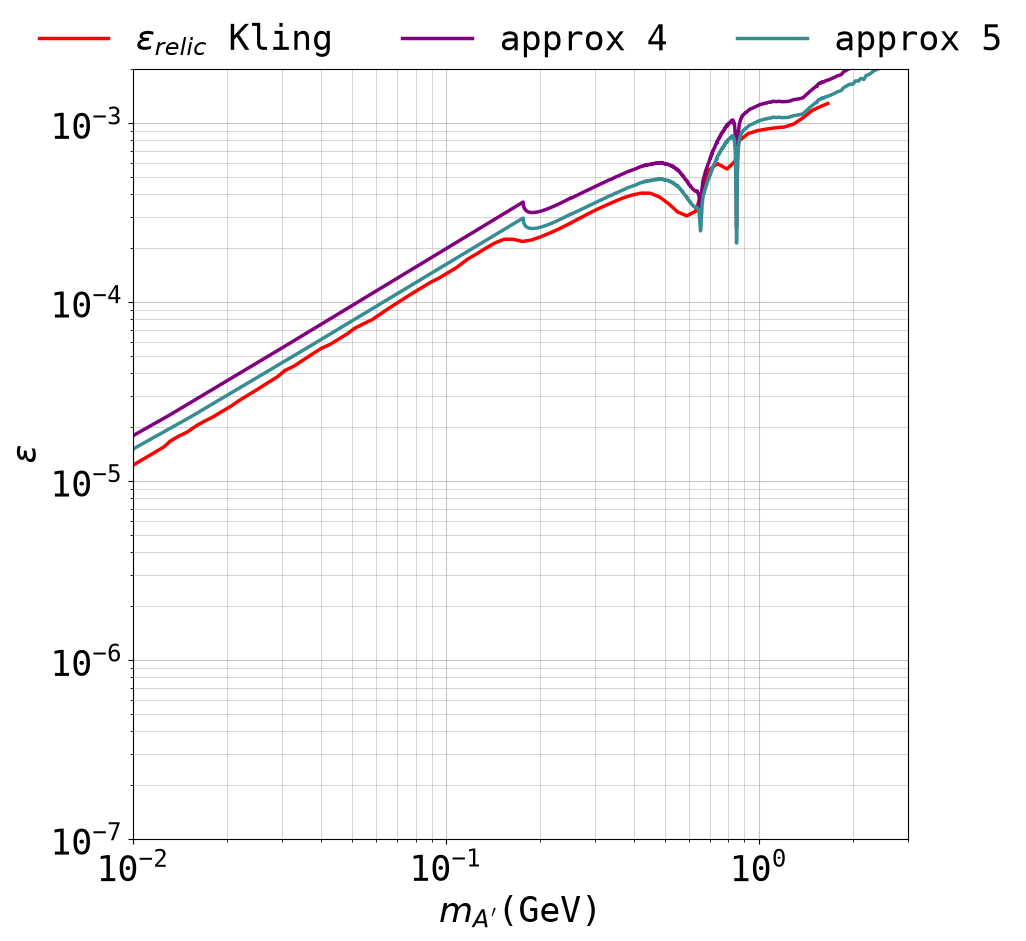

In [110]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")
#plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label = r"approx 1")
#plt.plot(ma, eps_approx_1, color = 'black', linewidth = 2.5, label = r"approx 2")
#plt.plot(ma, eps_approx_2, color = 'green', linewidth = 2.5, label = r"approx 3")
plt.plot(ma, eps_approx_3, color = 'purple', linewidth = 2.5, label = r"approx 4")
plt.plot(ma, eps_approx_4, color = '#378d94', linewidth = 2.5, label = r"approx 5")

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

### Using the Boltzmann equation:

The complete and more accurate way of solving for the relic abundance comes from solving the Boltzmann equation for out-of-equilibrium particle numbers. Through some standard procedures I will omit, the differential equation can be written in term of the adimensional variable $Y_\chi$, defined as (note some conventions differ on the normalization. We are taking Kolb and Turner's normalization):

$$
Y_{\chi} = \frac{n_\chi}{s},
$$

where $s$ is the entropy density, which can be written as a function of $x$ (or temperature):

$$
s = \frac{2 \pi^2}{45} g_{*s}\left( \frac{m_\chi}{x} \right) \left( \frac{m_\chi}{x} \right)^3,
$$

and $g_{*s}$ are the relativistic degrees of freedom in entropy. The intermediate behaviour of $g_{*s}$ is relatively complicated, and can change abruptly close to the QCD phase transition (confinement into hadrons). For that reason, we use tabulated values interpolated into a functional form.

The Boltmann equation in terms of $Y$ are known as the Riccati equations:

$$
\frac{dY}{dx} = \frac{1}{2} \frac{1}{3H(x)} \frac{ds}{dx} \left\langle \sigma v \right\rangle \left(  Y^2 - Y^2_{\text{eq}}\right)
$$

$$
\frac{ds}{dx} = - \frac{2 \pi^2}{45}  \frac{m_\chi^3}{x^4}  \left( 3 +  \frac{d \ln g_{*s}}{d \ln T}\left( \frac{m_\chi}{x} \right) \right)
$$
If we assume radiation domination at the relevant temperatures, then the Hubble parameter might be written as:
$$
H(T) = \sqrt{\frac{\pi^2}{90}g_{*}(T)}\frac{T^2}{M_{\text{Pl}}},
$$
where $g_*$ is now the relativistic degrees of freedom in the energy density.

We also have that $Y_{\text{eq}}$ can be written in the limit of $x \gg 3$ as:
$$
Y_{\text{eq}} = \frac{45}{2 \pi^2} \frac{g}{g_{*s}(m_\chi/x)} \left( \frac{x}{2 \pi} \right)^{3/2} e^{-x}.
$$

Using these approximations we can integrate the diferential equation to obtain the $Y_\infty$:


In [111]:
# Defining the Riccati equation

def H(T): # Assuming radiation domination
    return np.sqrt(np.pi**2/90 * gstarfun(T))*T**2/Mpl

def s(mchi, x):
    return 2*np.pi**2/45 * gstarsfun(mchi/x)*mchi**3/x**3

def Yeq(x, g, mchi):
    return 45/(2*np.pi**2)* g/gstarsfun(mchi/x) * (x/(2*np.pi))**(3/2) * np.exp(-x)


### The entropy release. Writing the equation as dY/dx = -<sigma v> s/(x H)
### silently assumes g*_s is constant: it uses s a^3 = const to turn dn/dt +
### 3Hn into a plain dY/dt, and T ~ 1/a to turn dt into dx. Neither holds
### while a species is annihilating away. Keeping ds/dx explicit puts that
### back, and costs one derivative of the tabulated g*_s.

def dlogglogT(T, h=0.05):
    """d ln g*_s / d ln T, by central difference on the interpolated table.

    The table steps discontinuously at the QCD transition, where the exact
    derivative is a delta function. A finite h in ln T smears that step over
    a fraction of a decade instead, which is what keeps ds/dx bounded.
    """
    T = np.asarray(T, dtype=float)
    lT = np.log(T)
    return (np.log(gstarsfun(np.exp(lT + h)))
            - np.log(gstarsfun(np.exp(lT - h))))/(2*h)


def dsdx(x, mchi):
    """ds/dx at T = mchi/x, with s = (2 pi^2/45) g*_s(T) T^3.

        ds/dx = -(2 pi^2/45) (mchi^3/x^4) g*_s(T) [ 3 + d ln g*_s/d ln T ]

    Drop the second term in the bracket and this is -3 s/x, which is what
    the constant g*_s form assumes.
    """
    T = mchi/x
    return -(2*np.pi**2/45)*mchi**3/x**4*gstarsfun(T)*(3 + dlogglogT(T))


def dYdxcore(x, Y, g, mchi, sigmav):
    """Shared right hand side, Gelmini form:

        dY/dx = 1/(2 * 3 H(x)) ds/dx <sigma v> ( Y^2 - Y_eq^2 )

    ds/dx < 0, so this depletes Y whenever Y > Y_eq. H is evaluated at the
    running T = mchi/x rather than at mchi, so g*_e is read where it is
    actually needed.

    Every treatment below goes through here and supplies its own <sigma v>:
    the velocity expansion, the Dirac cross section, and the full thermal
    average all differ in that argument and in nothing else.
    """
    return dsdx(x, mchi)/(2*3*H(mchi/x))*sigmav*(Y**2 - Yeq(x, g, mchi)**2)


def dYdx(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Scalar DM, <sigma v> from the 6/x velocity expansion."""
    return dYdxcore(x, Y, g, mchi,
                    sigmavrel(vare, ma, alpha, alphaD, mchi, x))


xi = 10
xf = 1000

dYdxsolver = lambda x,Y: dYdx(x, Y, g = 2, vare = 1e-3, ma = 1e-1, alpha = 1/137, alphaD = 0.1, mchi = 0.6*1e-1)

xarr = np.logspace(np.log10(xi), np.log10(xf), 10000)
sol = solve_ivp(dYdxsolver, (xarr[0], xarr[-1]), [Yeq(xi,2, mchi=0.6*1e-1)],
                method="Radau", first_step=1e-10,
                t_eval=xarr, rtol=1e-8, atol=1e-12)

In [112]:
def omega(mchi, Yinf):
    return mchi*Yinf*(2*np.pi**2/45)*gstarsT0*T0**3/(3*Mpl**2*H0**2) 

Finally, to translate $Y_\infty$ into the observed relic abundance of dark matter today, we have that for isentropic expansion (constant entropy per comoving volume) the number density of the species is simply:
$$
n_{\chi,0} = s_0 Y_\infty.
$$
Multiplying by the mass and dividing by the critical density, we obtain that the relic abundance can be simply written as:
$$
\Omega_{\chi} = \frac{2 \pi^2}{45} \frac{m_\chi}{3 H_0^2 M_{\text{pl}}^2} T_0^2 g_{*s}(T_0) Y_\infty.
$$

To reproduce the correct relic abundance, we must scan over the different parameters available for the model $\alpha_D$, $m_\chi$, $m_{A'}$ and $\epsilon$, which are encoded inside the annihilation cross section.

In [113]:
### Scan over (ma, vare) for the epsilon that reproduces the observed Omega.

# The model parameters are alphaD, ma, mchi and vare. Only ma and vare are
# scanned: alphaD is held fixed, and mchi is tied to ma by mchi_over_ma,
# since the relic line is drawn at a fixed mass ratio. Omega ~ 1/(alphaD *
# vare^2), so alphaD shifts the answer as hard as vare does -- at alphaD = 1
# the crossing leaves the vare window over most of the mass range, at 0.1 it
# sits inside it.

def omega_of(ma, vare, alphaD, mchi_over_ma=0.6,
             xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point, by integrating the Boltzmann eq.

    xi = 10 is safely inside equilibrium (freeze-out is near x ~ 20-25) and
    xfin = 1e3 leaves Y converged to a few times 1e-4; both were chosen by
    measuring, and the cost is dominated by the freeze-out transition rather
    than by the tail.
    """
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdx(x, Y, 2, vare, ma, alpha, alphaD, mchi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

def solve_window(omfun, ma, v_lo, v_hi, target, tol=0.01, itmax=30):
    """Find the crossing Omega(vare) = target inside [v_lo, v_hi].

    omfun(ma, vare) supplies Omega, so the caller controls alphaD, the mass
    ratio and the solver settings, and can count the calls.

    Omega falls monotonically with vare, so the two ends of the window
    either bracket the target or nothing inside it does. Take the bottom and
    the top first: Omega(v_lo) is the most DM the window can give and
    Omega(v_hi) the least, so those same two values also say which side of
    the window the crossing lies on.

    Then, instead of splitting the bracket down the middle, probe where the
    straight line through its two ends crosses the target. log Omega is very
    nearly linear in log vare (slope about -1.8), so that probe lands almost
    on the root: about four solves in total, against the nine or so halvings
    a factor-200 window would otherwise need.

    Returns (eps, side), side being 'inside', 'below', 'above', or None if
    the solver failed.
    """
    om_lo = omfun(ma, v_lo)
    if np.isfinite(om_lo) and om_lo < target:
        return np.nan, "below"       # needs a smaller vare than the window holds
    om_hi = omfun(ma, v_hi)
    if np.isfinite(om_hi) and om_hi > target:
        return np.nan, "above"       # needs a larger vare than the window holds
    if not (np.isfinite(om_lo) and np.isfinite(om_hi)):
        return np.nan, None

    lo, hi = np.log(v_lo), np.log(v_hi)
    f_lo, f_hi = np.log(om_lo/target), np.log(om_hi/target)   # f_lo > 0 > f_hi
    held = 0

    for _ in range(itmax):
        # Where the chord through (lo, f_lo) and (hi, f_hi) hits zero:
        probe = (lo*f_hi - hi*f_lo)/(f_hi - f_lo)
        om_p = omfun(ma, float(np.exp(probe)))
        if not np.isfinite(om_p) or om_p <= 0:
            return np.nan, None
        f_p = np.log(om_p/target)
        if abs(f_p) < tol:
            return float(np.exp(probe)), "inside"

        if f_p > 0:                  # still too much DM, so vare must rise
            # Illinois tweak: if the same end keeps being replaced the other
            # one goes stale and the probe crawls, so halve its weight.
            if held > 0:
                f_hi *= 0.5
            lo, f_lo, held = probe, f_p, 1
        else:
            if held < 0:
                f_lo *= 0.5
            hi, f_hi, held = probe, f_p, -1

    # Tolerance never met: interpolate across what is left of the bracket,
    # which costs nothing since both ends are already known.
    return float(np.exp((lo*f_hi - hi*f_lo)/(f_hi - f_lo))), "inside"

# log Omega vs log vare is close to a straight line of slope -2, but not
# exactly, because the freeze-out x drifts with the coupling. Measured ~-1.8.
LOGSLOPE = -1.8

def predict_eps(i, ma_grid, eps_found):
    """Extrapolate eps for mass i from the last two solved masses.

    Just re-centring on the previous eps systematically undershoots, since
    eps(ma) is rising; continuing the local power law lands much closer and
    saves an iteration or two per mass.

    Returned UNCLIPPED on purpose: an out-of-window prediction is the signal
    that the relic line may have left the scan range.
    """
    solved = [(m, e) for m, e in zip(ma_grid[:i], eps_found[:i]) if np.isfinite(e)]
    if not solved:
        return None
    if len(solved) == 1:
        return solved[-1][1]
    (m1, e1), (m2, e2) = solved[-2], solved[-1]
    slope = np.log(e2/e1)/np.log(m2/m1)
    return float(e2*(ma_grid[i]/m2)**slope)

def refine_eps(omfun, ma, guess, v_lo, v_hi, target, tol=0.01, itmax=6):
    """Walk from a nearby guess to the crossing Omega = target.

    One ODE solve per step, and LOGSLOPE turns each into a Newton step, so
    this lands within tol of the target in a handful of solves. Returns nan
    if it walks outside [v_lo, v_hi].
    """
    le = np.log(guess)
    for _ in range(itmax):
        om = omfun(ma, float(np.exp(le)))
        if not np.isfinite(om) or om <= 0:
            return np.nan
        r = np.log(om/target)
        if abs(r) < tol:
            return float(np.exp(le))
        le += r/(-LOGSLOPE)
        if not (np.log(v_lo) <= le <= np.log(v_hi)):
            return np.nan
    return float(np.exp(le))

def scan_relic_line(ma_grid, vare_lo, vare_hi, alphaD, mchi_over_ma=0.6,
                    target=None, tol=0.01, solver=None, verbose=True,
                    omega_fun=None):
    """eps(ma) reproducing the relic abundance, at fixed alphaD and mass ratio.

    Scans only ma and vare: ma over ma_grid, vare bracketed by
    [vare_lo, vare_hi]. alphaD is fixed, and mchi = mchi_over_ma*ma.

    Every mass after the first starts from the ones already solved and only
    looks nearby. Anything that fails there -- the first mass, an
    extrapolation that has left the window, a Newton walk that wandered off
    -- falls back to searching the whole window, which also reports which
    side of it the crossing lies on.

    eps(ma) rises monotonically, so the line can leave the window in two
    ways and they need opposite responses:
      - below the window, at the light end, before it has ever been found:
        keep going, the line is climbing and may still enter the range;
      - above the window, at the heavy end: nothing further can be solved,
        so stop rather than search on every remaining mass.

    solver is an optional dict of keywords forwarded to omega_fun (xi, xfin,
    rtol, atol). omega_fun defaults to omega_of, the scalar model; pass
    omega_of_dirac for the Dirac fermion. Everything else here -- the
    bracketing, the warm start, the early stop -- only sees Omega(ma, vare)
    and so is shared between the two.

    Returns (eps, info) with eps a masked-by-nan array over ma_grid, and info
    carrying the solve count and why the scan stopped.
    """
    if omega_fun is None:
        omega_fun = omega_of
    if target is None:
        target = OmegaDM
    ma_grid = np.asarray(ma_grid, dtype=float)
    stats = {"nsolve": 0}

    def omfun(ma, vare):
        stats["nsolve"] += 1
        return omega_fun(ma, vare, alphaD, mchi_over_ma, **(solver or {}))

    eps = np.full(ma_grid.shape, np.nan)
    stop_note = None
    i_stop = len(ma_grid)

    for i, ma_i in enumerate(ma_grid):
        guess = predict_eps(i, ma_grid, eps)

        found = np.nan
        if guess is not None and vare_lo <= guess <= vare_hi:
            found = refine_eps(omfun, ma_i, guess, vare_lo, vare_hi, target, tol)

        if not np.isfinite(found):
            found, side = solve_window(omfun, ma_i, vare_lo, vare_hi, target, tol)
            if side == "above":
                stop_note = (f"crossing lies above the window at ma = {ma_i:.4g} GeV"
                             + (f" (extrapolated eps = {guess:.3e} > {vare_hi:g})"
                                if guess is not None else ""))
                i_stop = i
                break
            # 'below' or None: the line is not in range here, carry on

        eps[i] = found

    nfound = int(np.isfinite(eps).sum())
    info = {"nsolve": stats["nsolve"], "nfound": nfound,
            "stop_note": stop_note, "i_stop": i_stop,
            "alphaD": alphaD, "mchi_over_ma": mchi_over_ma, "target": target,
            "model": omega_fun.__name__}

    if verbose:
        print(f"alphaD = {alphaD:g}, mchi/ma = {mchi_over_ma:g},"
              f" Omega target = {target:g}")
        print(f"solved {nfound} of {len(ma_grid)} masses in {stats['nsolve']}"
              f" ODE integrations ({stats['nsolve']/max(nfound, 1):.1f} per solved mass)")
        if stop_note is not None:
            print(f"stopped early at index {i_stop}: {stop_note}")
            print(f"  {len(ma_grid) - i_stop} masses left unscanned"
                  f" (ma >= {ma_grid[i_stop]:.4g} GeV)")
        if nfound:
            got = ma_grid[np.isfinite(eps)]
            print(f"  solved range ma = {got[0]:.4g} to {got[-1]:.4g} GeV")
        else:
            print(f"no vare in [{vare_lo:g}, {vare_hi:g}] reaches {target};"
                  f" Omega(ma={ma_grid[0]:.3g}, vare={vare_lo:g})"
                  f" = {omfun(ma_grid[0], vare_lo):.3e}")
    return eps, info

In [114]:
### Running the scan:

ma_scan1 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo1, vare_hi1 = 1e-5, 2e-3

eps_relic1, scan_info1 = scan_relic_line(ma_scan1, vare_lo1, vare_hi1,
                                       alphaD=0.1, mchi_over_ma=0.6)

KeyboardInterrupt: 

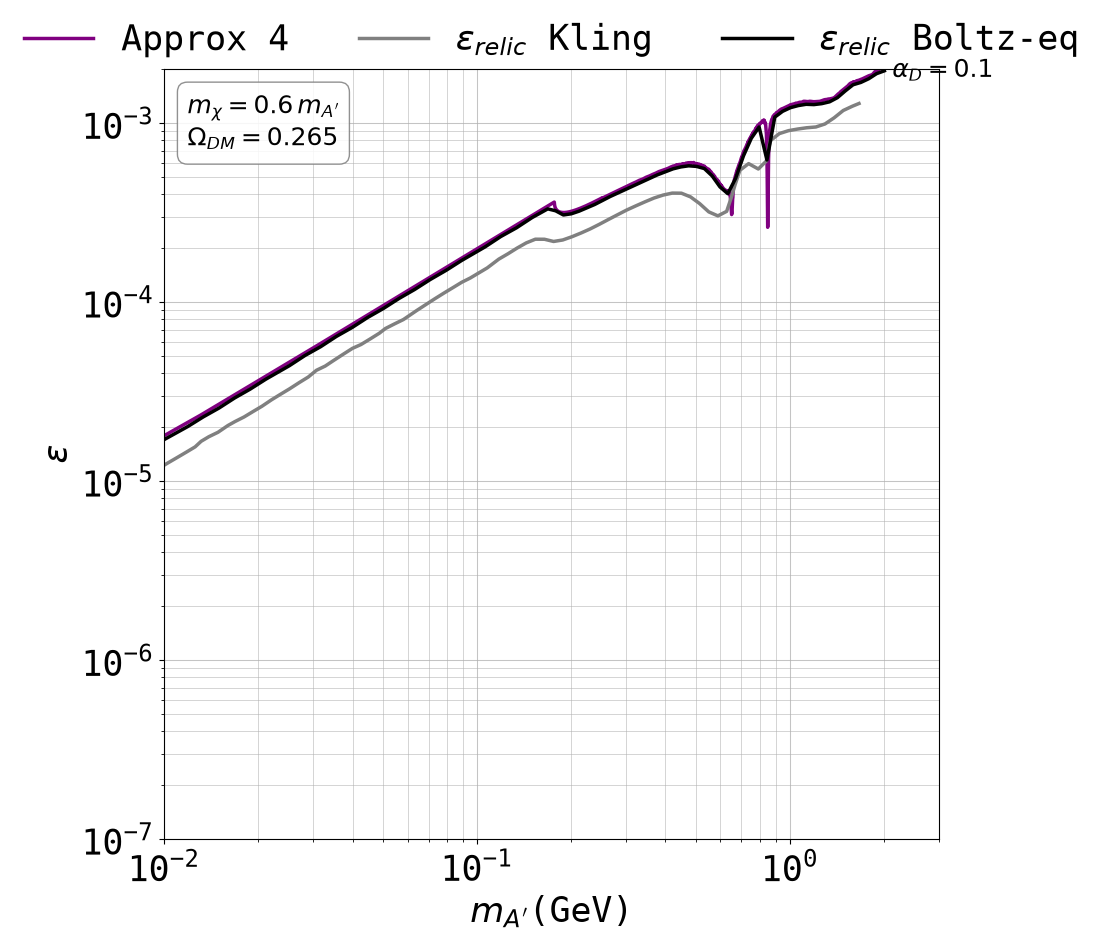

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

#plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Approx 1")
#plt.plot(ma, eps_approx_1, color = 'red', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Approx 2")
#plt.plot(ma, eps_approx_2, color = 'green', linewidth = 2.5, label = r"$\epsilon_{relic}$ Approx 3")
plt.plot(ma, eps_approx_3, color = 'purple', linewidth = 2.5, label = r"Approx 4")
plt.plot(ma_kling, eps_kling, color = 'grey', linewidth = 2.5,
         label = r"$\epsilon_{relic}$ Kling")



plt.plot(ma_scan1, eps_relic1, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over. Both the
## shared box and the per-curve labels are read back out of the scan info
## dicts, so the annotation cannot drift away from what was actually run.

relic_curves = [(ma_scan1, eps_relic1, scan_info1)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}
if len(fixed_ratio) > 1:
    print("warning: the box states a single mchi/ma, but the curves use",
          sorted(fixed_ratio))

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## alphaD differs between the Boltzmann curves here, so it is tagged on each
## one at its end rather than collected in the box, where it could not say
## which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1, 2]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_0.pdf", bbox_inches='tight')
plt.show()

### The better thermal averaging

Following Gelmini. The evolution of $Y$ as defined before comes as:

$$
\frac{dY}{dx} = \frac{1}{2} \frac{1}{3H(x)} \frac{ds}{dx} \left\langle \sigma v_{\text{Møller}} \right\rangle \left(  Y^2 - Y^2_{\text{eq}}\right)
$$

$$
\frac{ds}{dx} = - \frac{2 \pi^2}{45}  \frac{m_\chi^3}{x^4}  \left( 3 +  \frac{d \ln g_{*s}}{d \ln T}\left( \frac{m_\chi}{x} \right) \right)
$$

However, the thermal averaging must come as:

$$
\left\langle \sigma v_{\text{Møller}} \right\rangle = \frac{1}{8 m_\chi^4 (m_\chi/x) K_2^2(x)}  \int_{4 m_\chi^2}^\infty \sigma (s - 4m_\chi^2) \sqrt{s} K_1(\sqrt{s}x/m_\chi)ds
$$

Where $K_i$ are the modified Bessel functions of the second kind

$$
\sigma (s) = 2 \pi \epsilon^2 \alpha \alpha_D \frac{\left(s - 4 m_\chi^2 \right)^{1/2}}{s \left(s - m_{A'}^2 \right)^2} \left[ \sum_\ell \tilde{\sigma}_\ell(s) + R(\sqrt{s}) \tilde{\sigma}_\mu(s)  \right]
$$ 

where we defined the sigma tilde as:

$$
 \tilde{\sigma}_f (s) = Q_f^2 N_c^f \left(s - 4 m_f^2 \right)^{1/2} \left( s - \frac{1}{3} \left(s - 4 m_f^2 \right) \right) \Theta \left( \sqrt{s} - 2 m_f \right)
$$


In [ ]:
### Gondolo-Gelmini thermal averaging.
###
### The Boltzmann equation itself is already in place: dYdxcore carries the
### ds/dx and the running H. The only thing that changes here is <sigma v>,
### which stops being the leading term of a velocity expansion and becomes
### the exact average over the thermal distribution of s.

from scipy.special import kve

def sigmatilde(s, mf, Q2Nc=1.0):
    """Q_f^2 N_c^f (s - 4mf^2)^{1/2} ( s - (s - 4mf^2)/3 ), zero below threshold.

    The bracket is (2/3)(s + 2 mf^2), the usual vector current factor. The
    sqrt is only evaluated where the channel is open, so closed channels
    contribute an exact 0 rather than a nan, as Kl does for the expansion.
    """
    s = np.asarray(s, dtype=float)
    opench = s > 4*mf**2
    beta2 = np.where(opench, s - 4*mf**2, 0.0)
    return Q2Nc*np.where(opench, np.sqrt(beta2)*(s - beta2/3), 0.0)


def sigma_ann(s, vare, ma, alpha, alphaD, mchi):
    """chi chi -> f fbar annihilation cross section at Mandelstam s.

    sigma(s) = 2 pi eps^2 alpha alphaD (s - 4mchi^2)^{1/2} / [ s (s - ma^2)^2 ]
               * [ sum_l sigmatilde_l(s) + R(sqrt(s)) sigmatilde_mu(s) ].

    The hadronic piece reuses R and the muon normalisation from the velocity
    expansion, so both treatments read the same PDG table. Here R is sampled
    at the running sqrt(s) instead of at 2*mchi, which is the point of the
    exercise: the average below smears the rho, omega and phi peaks rather
    than reading them off at a single energy.
    """
    s = np.asarray(s, dtype=float)
    opench = s > 4*mchi**2
    beta_chi = np.where(opench, np.sqrt(np.where(opench, s - 4*mchi**2, 0.0)), 0.0)

    lept = np.zeros_like(s)
    for ml in mleptons:
        lept = lept + sigmatilde(s, ml)
    hadr = R(np.sqrt(s))*sigmatilde(s, mleptons[1])

    return np.where(opench,
                    2*np.pi*vare**2*alpha*alphaD*beta_chi
                    / (s*(s - ma**2)**2)*(lept + hadr),
                    0.0)


# How far past threshold to integrate, in units of T, and how many nodes.
# The integrand dies as exp[-(sqrt(s) - 2 mchi)/T], so 60 T is a cut at
# e^-60; the grid is uniform in sqrt(s) so the narrow phi (4 MeV) and omega
# (8 MeV) are resolved rather than stepped over.
GG_UCUT = 60.0
GG_NODES = 4001


def sigmav_moller(x, vare, ma, alpha, alphaD, mchi,
                  ucut=GG_UCUT, nodes=GG_NODES):
    """<sigma v_Moller>(x), Gondolo-Gelmini.

        <sigma v> = 1/(8 mchi^4 T K2(x)^2)
                    * int_{4mchi^2}^inf sigma(s) (s - 4mchi^2) sqrt(s)
                                        K1(sqrt(s) x/mchi) ds

    Integrated in w = sqrt(s) (ds = 2w dw), which puts the threshold at the
    fixed point w = 2 mchi and makes the decay a plain e^-u in the variable
    u = (w - 2 mchi)/T.

    The Bessel functions are exponentially scaled: K1(z) = kve(1,z) e^-z and
    K2(x) = kve(2,x) e^-x, so their ratio carries exp(2x - z) = e^-u with
    u >= 0. Nothing overflows, which bare kv would past x ~ 700.
    """
    x = float(x)
    T = mchi/x
    u = np.linspace(0.0, ucut, nodes)          # (sqrt(s) - 2 mchi)/T
    w = 2*mchi + u*T                           # sqrt(s)
    s = w*w

    sig = sigma_ann(s, vare, ma, alpha, alphaD, mchi)
    z = w*x/mchi                               # = 2x + u
    bessel = kve(1, z)/kve(2, x)**2*np.exp(-u)

    integrand = 2*sig*(s - 4*mchi**2)*w*w*bessel   # the 2w from ds = 2w dw
    return np.trapezoid(integrand, w)/(8*mchi**4*T)


def dYdxgg(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Scalar DM, <sigma v> from the full thermal average.

    Same dYdxcore as dYdx, same Yeq, same ds/dx, same H. sigmav_moller in
    place of sigmavrel is the only difference between the two.
    """
    return dYdxcore(x, Y, g, mchi,
                    sigmav_moller(x, vare, ma, alpha, alphaD, mchi))


def Yeqgg(x, g, mchi):
    """Exact Bessel Y_eq, 45 g x^2 K2(x) / (4 pi^4 g*_s(T)).

    Not used by anything above: dYdx and dYdxgg share the Maxwell-Boltzmann
    Yeq so that <sigma v> stays the only difference between them. Kept
    because it is the one to switch BOTH to if the integration ever has to
    start at x < 3, where the non-relativistic Yeq is no longer valid.
    """
    x = np.asarray(x, dtype=float)
    return 45*g*x**2*kve(2, x)*np.exp(-x)/(4*np.pi**4*gstarsfun(mchi/x))

In [ ]:
### Making the thermal average cheap enough to scan with.
###
### Three things make the direct sigmav_moller too slow for a scan. It is
### recomputed for every vare although eps^2 alpha alphaD only multiplies it;
### it is recomputed at every step the ODE solver takes, although it depends
### on nothing the solver changes; and it carries 4001 nodes everywhere,
### although only the rho/omega/phi window needs them. All three are fixed
### below, and none of them changes the integrand.

from scipy.integrate import simpson

# sqrt(s) window over which R is resonance dominated and the grid has to stay
# fine. Below 0.3 GeV R is identically 0 (nothing is tabulated), and above
# the phi it is a slowly varying continuum.
GG_RES_LO, GG_RES_HI = 0.28, 1.15
GG_NODES_SMOOTH = 601      # no resonance in the window: the integrand is just u^(3/2) e^-u
GG_DW_RES = 5e-4           # target sqrt(s) spacing in GeV inside the window (phi is 4 MeV)
GG_NODES_MAX = 24001


def gg_grid(mchi, T, ucut=GG_UCUT):
    """Integration nodes in u = (sqrt(s) - 2 mchi)/T, uniform in sqrt(s).

    Cheap when the thermal window misses the resonances entirely, which is
    the case for most of the mass range, and dense enough to resolve the phi
    when it does not.
    """
    wlo, whi = 2*mchi, 2*mchi + ucut*T
    if whi < GG_RES_LO or wlo > GG_RES_HI:
        nodes = GG_NODES_SMOOTH
    else:
        nodes = int(np.clip((whi - wlo)/GG_DW_RES, GG_NODES_SMOOTH, GG_NODES_MAX))
    nodes += 1 - nodes % 2          # simpson wants an odd node count
    return np.linspace(0.0, ucut, nodes)


def sigmav_moller_unit(x, ma, mchi, ucut=GG_UCUT):
    """<sigma v_Moller>(x) with eps^2 alpha alphaD divided out.

    sigma_ann is linear in that product, so it factors straight through the
    integral. Everything the scan varies with vare is therefore outside, and
    one of these serves every epsilon at a given (ma, mchi).
    """
    x = float(x)
    T = mchi/x
    u = gg_grid(mchi, T, ucut)
    w = 2*mchi + u*T
    s = w*w

    sig = sigma_ann(s, 1.0, ma, 1.0, 1.0, mchi)
    bessel = kve(1, 2*x + u)/kve(2, x)**2*np.exp(-u)
    return simpson(2*sig*(s - 4*mchi**2)*w*w*bessel, x=w)/(8*mchi**4*T)


# One interpolant per (ma, mchi). The ODE solver asks for <sigma v> at a few
# thousand values of x per integration and the bisection re-integrates a
# handful of times per mass, so this table is built once and read a few tens
# of thousands of times.
GG_XLO, GG_XHI, GG_XPTS = 2.0, 3e3, 193
_gg_cache = {}


def sigmav_unit_table(ma, mchi):
    """log-log cubic interpolant of sigmav_moller_unit in x, memoised.

    log F is very nearly linear in log x (F ~ 1/x for a p-wave), so a cubic
    over three decades sits far below the tolerance the ODE is integrated to.
    Checked in the cell below rather than assumed.
    """
    key = (float(ma), float(mchi))
    tab = _gg_cache.get(key)
    if tab is None:
        xg = np.logspace(np.log10(GG_XLO), np.log10(GG_XHI), GG_XPTS)
        Fg = np.array([sigmav_moller_unit(_x, ma, mchi) for _x in xg])
        tab = interpolate.interp1d(np.log(xg), np.log(Fg), kind="cubic",
                                   bounds_error=False,
                                   fill_value=(np.log(Fg[0]), np.log(Fg[-1])))
        _gg_cache[key] = tab
    return tab


def sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi):
    """Drop-in for sigmavrel, reading the memoised table."""
    return (vare**2*alpha*alphaD
            * np.exp(sigmav_unit_table(ma, mchi)(np.log(x))))


def dYdxggf(x, Y, g, vare, ma, alpha, alphaD, mchi):
    """Same dYdxcore as dYdx, with the tabulated thermal average."""
    return dYdxcore(x, Y, g, mchi,
                    sigmav_moller_fast(x, vare, ma, alpha, alphaD, mchi))


def omega_of_gg(ma, vare, alphaD, mchi_over_ma=0.6,
                xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega with the full thermal average.

    Same signature and same solver settings as omega_of, so scan_relic_line
    takes either one through its omega_fun argument and the two lines differ
    only in <sigma v>.
    """
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxggf(x, Y, 2, vare, ma, alpha, alphaD, mchi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

In [ ]:
### Both treatments on one mass grid, against Kling.
###
### The grid is deliberately lopsided: 14 points carry the whole smooth
### stretch below 0.4 GeV, and 34 sit between 0.4 and 1.2 GeV, where
### sqrt(s) = 1.2 ma sweeps the rho, the omega and the phi. That is the only
### place the two averagings can be told apart, so that is where the masses
### go.

ma_moller = np.unique(np.concatenate([
    np.logspace(np.log10(0.012), np.log10(0.40), 14),
    np.logspace(np.log10(0.40),  np.log10(1.20), 34),
    np.logspace(np.log10(1.20),  np.log10(1.62),  4)]))

eps_exp_m, info_exp_m = scan_relic_line(ma_moller, 1e-6, 5e-3, alphaD=0.1,
                                        mchi_over_ma=0.6, omega_fun=omega_of)
eps_gg, info_gg = scan_relic_line(ma_moller, 1e-6, 5e-3, alphaD=0.1,
                                  mchi_over_ma=0.6, omega_fun=omega_of_gg)

### Kling on the same masses, and the two ratios to it. Split at the window
### where R is resonance dominated, because the two averagings are supposed
### to differ there and nowhere else.

eps_kling_on_grid = np.exp(np.interp(np.log(ma_moller),
                                     np.log(ma_kling), np.log(eps_kling)))
inres = (ma_moller >= 0.50) & (ma_moller <= 0.92)

print("\n  m_A'     Kling     expansion  ratio     Moller    ratio")
for _i, _m in enumerate(ma_moller):
    print(f"{_m:7.4f} {eps_kling_on_grid[_i]:.3e}  {eps_exp_m[_i]:.3e} {eps_exp_m[_i]/eps_kling_on_grid[_i]:6.3f}"
          f"   {eps_gg[_i]:.3e} {eps_gg[_i]/eps_kling_on_grid[_i]:6.3f}")

print()
for _nm, _e in [("expansion", eps_exp_m), ("Moller   ", eps_gg)]:
    _r = _e/eps_kling_on_grid
    for _lab, _mask in [("smooth   ", ~inres), ("resonance", inres)]:
        _rr = _r[_mask]
        print(f"  {_nm} {_lab}: median {np.median(_rr):.3f}"
              f"   scatter in log {np.std(np.log(_rr/np.median(_rr))):.4f}"
              f"   range {_rr.min():.3f} - {_rr.max():.3f}")

alphaD = 0.1, mchi/ma = 0.6, Omega target = 0.265
solved 50 of 50 masses in 90 ODE integrations (1.8 per solved mass)
  solved range ma = 0.012 to 1.62 GeV
alphaD = 0.1, mchi/ma = 0.6, Omega target = 0.265
solved 50 of 50 masses in 91 ODE integrations (1.8 per solved mass)
  solved range ma = 0.012 to 1.62 GeV

  m_A'     Kling     expansion  ratio     Moller    ratio
 0.0120 1.479e-05  2.034e-05  1.376   2.654e-05  1.795
 0.0157 2.000e-05  2.700e-05  1.350   3.504e-05  1.752
 0.0206 2.621e-05  3.585e-05  1.368   4.627e-05  1.765
 0.0270 3.535e-05  4.759e-05  1.346   6.109e-05  1.728
 0.0353 4.787e-05  6.317e-05  1.320   8.139e-05  1.700
 0.0462 6.316e-05  8.454e-05  1.339   1.084e-04  1.717
 0.0605 8.363e-05  1.131e-04  1.353   1.432e-04  1.713
 0.0793 1.135e-04  1.499e-04  1.321   1.892e-04  1.668
 0.1038 1.490e-04  1.986e-04  1.333   2.524e-04  1.693
 0.1360 2.025e-04  2.655e-04  1.311   3.366e-04  1.662
 0.1781 2.186e-04  3.243e-04  1.484   3.741e-04  1.711
 0.2332 2.590e-04  3.465

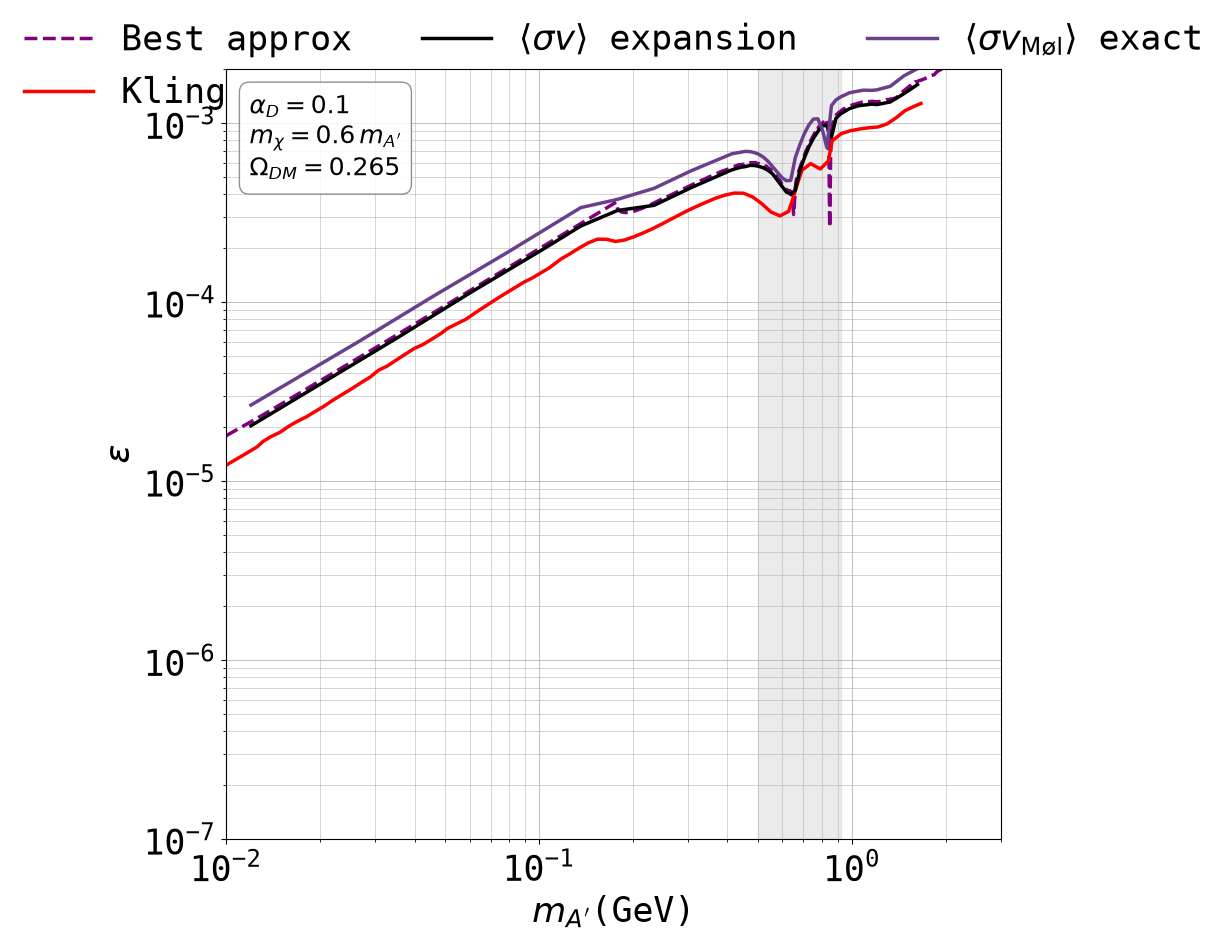

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma, eps_approx_3, linestyle='--', color = 'purple', linewidth = 2.5, label = r"Best approx")

plt.plot(ma_kling, eps_kling, color = 'red', linewidth = 2.5,
         label = r"Kling")
plt.plot(ma_moller, eps_exp_m, color = 'black', linewidth = 2.5,
         label = r"$\left\langle \sigma v \right\rangle$ expansion")
plt.plot(ma_moller, eps_gg, color = '#6a408d', linewidth = 2.5,
         label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact")

## Shade where R is resonance dominated, i.e. where the two averagings are
## expected to part company.
ax.axvspan(0.50, 0.92, color = '#7e7e7e', alpha = 0.15, zorder = 0)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % info_gg["alphaD"],
                   r"$m_\chi = %g\, m_{A'}$" % info_gg["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % info_gg["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 3,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min


# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_moller_0.pdf", bbox_inches='tight')
plt.show()

### Boltzmann equation scans for multiple parameters

We can run multiple scans for different $\alpha_D$ and $m_\chi/m_{A'}$:

In [ ]:
ma_scan2 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo2, vare_hi2 = 1e-7, 2e-3

eps_relic2, scan_info2 = scan_relic_line(ma_scan2, vare_lo2, vare_hi2,
                                       alphaD=0.95, mchi_over_ma=0.6)

alphaD = 0.95, mchi/ma = 0.6, Omega target = 0.265
solved 100 of 100 masses in 166 ODE integrations (1.7 per solved mass)
  solved range ma = 0.01 to 3 GeV


In [ ]:
ma_scan3 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo3, vare_hi3 = 1e-5, 2e-3

eps_relic3, scan_info3 = scan_relic_line(ma_scan3, vare_lo3, vare_hi3,
                                       alphaD=0.03, mchi_over_ma=0.6)

alphaD = 0.03, mchi/ma = 0.6, Omega target = 0.265
solved 79 of 100 masses in 131 ODE integrations (1.7 per solved mass)
stopped early at index 79: crossing lies above the window at ma = 0.9477 GeV (extrapolated eps = 3.421e-03 > 0.002)
  21 masses left unscanned (ma >= 0.9477 GeV)
  solved range ma = 0.01 to 0.8947 GeV


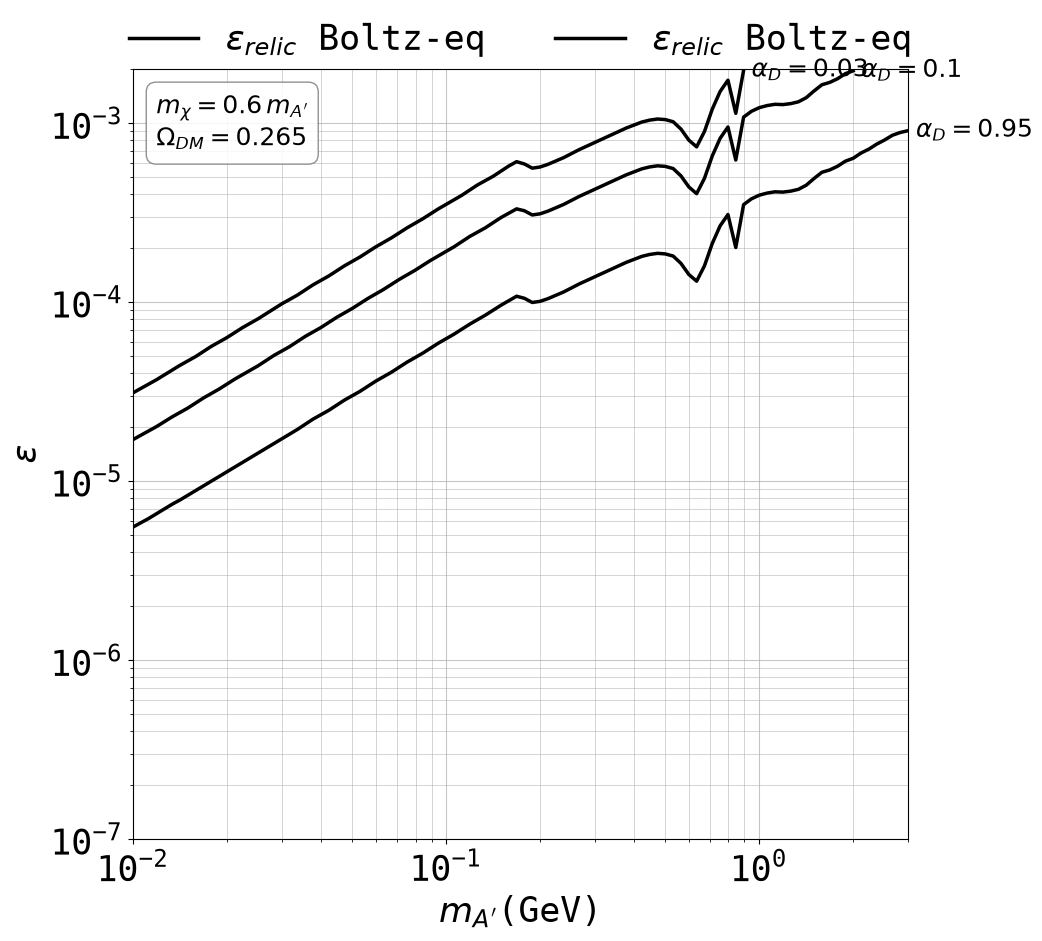

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_scan1, eps_relic1, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan2, eps_relic2, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan3, eps_relic3, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over. Both the
## shared box and the per-curve labels are read back out of the scan info
## dicts, so the annotation cannot drift away from what was actually run.

relic_curves = [(ma_scan1, eps_relic1, scan_info1),
                (ma_scan2, eps_relic2, scan_info2),
                (ma_scan3, eps_relic3, scan_info3)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}
if len(fixed_ratio) > 1:
    print("warning: the box states a single mchi/ma, but the curves use",
          sorted(fixed_ratio))

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## alphaD differs between the Boltzmann curves here, so it is tagged on each
## one at its end rather than collected in the box, where it could not say
## which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_1.pdf", bbox_inches='tight')
plt.show()

We can also scan over mass ratios, remembering $0.5 m_{A'} \leq m_\chi \leq m_{A'}$ 

In [ ]:
ma_scan4 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo4, vare_hi4 = 1e-5, 2e-3

eps_relic4, scan_info4 = scan_relic_line(ma_scan4, vare_lo4, vare_hi4,
                                       alphaD=0.1, mchi_over_ma=0.7)

alphaD = 0.1, mchi/ma = 0.7, Omega target = 0.265
solved 79 of 100 masses in 133 ODE integrations (1.7 per solved mass)
stopped early at index 79: crossing lies above the window at ma = 0.9477 GeV (extrapolated eps = 2.067e-03 > 0.002)
  21 masses left unscanned (ma >= 0.9477 GeV)
  solved range ma = 0.01 to 0.8947 GeV


In [ ]:
ma_scan5 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo5, vare_hi5 = 1e-5, 2e-3

eps_relic5, scan_info5 = scan_relic_line(ma_scan5, vare_lo5, vare_hi5,
                                       alphaD=0.1, mchi_over_ma=0.8)

alphaD = 0.1, mchi/ma = 0.8, Omega target = 0.265
solved 73 of 100 masses in 123 ODE integrations (1.7 per solved mass)
stopped early at index 73: crossing lies above the window at ma = 0.6708 GeV (extrapolated eps = 8.572e-04 > 0.002)
  27 masses left unscanned (ma >= 0.6708 GeV)
  solved range ma = 0.01 to 0.6332 GeV


In [ ]:
ma_scan6 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo6, vare_hi6 = 1e-5, 2e-3

eps_relic6, scan_info6 = scan_relic_line(ma_scan6, vare_lo6, vare_hi6,
                                       alphaD=0.1, mchi_over_ma=0.9)

alphaD = 0.1, mchi/ma = 0.9, Omega target = 0.265
solved 69 of 100 masses in 112 ODE integrations (1.6 per solved mass)
stopped early at index 69: crossing lies above the window at ma = 0.5327 GeV (extrapolated eps = 2.244e-03 > 0.002)
  31 masses left unscanned (ma >= 0.5327 GeV)
  solved range ma = 0.01 to 0.5029 GeV


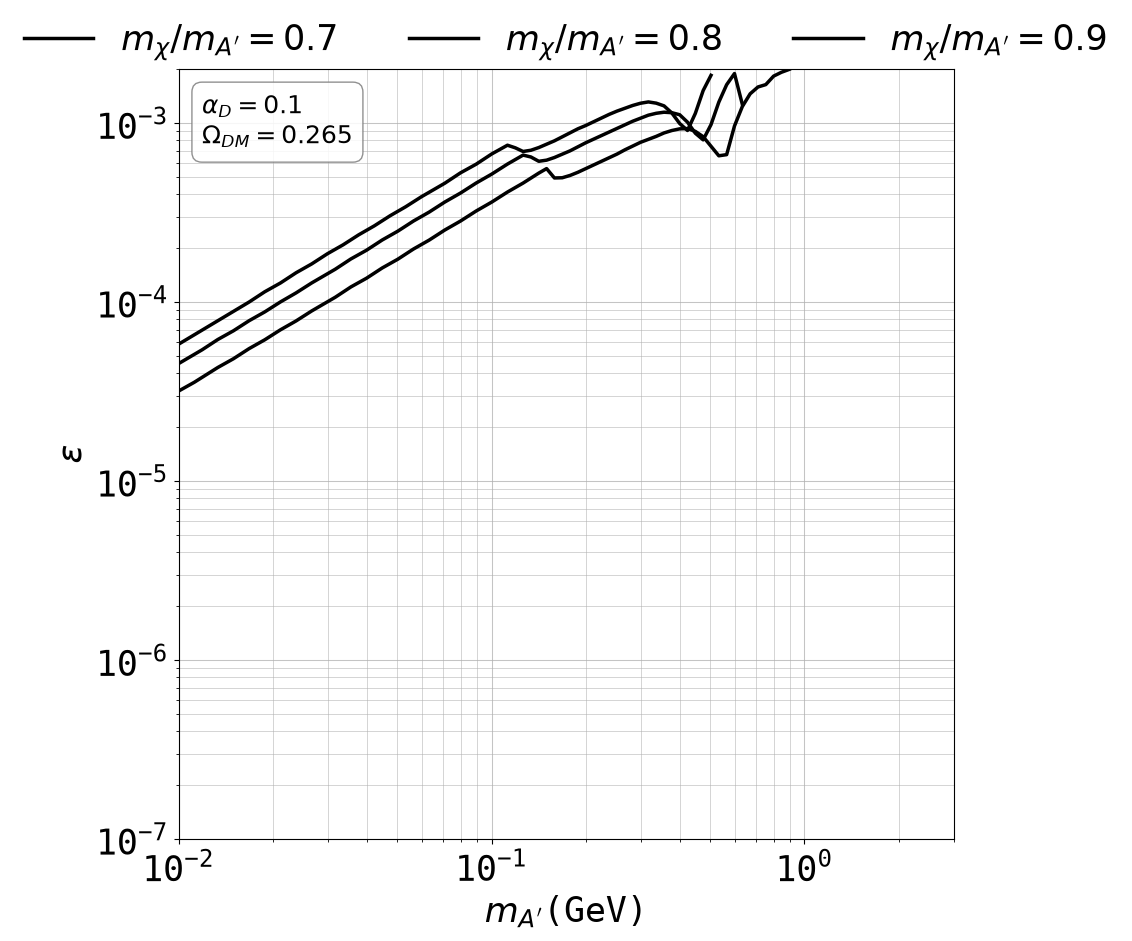

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

## On this figure mchi/ma is what varies between the curves, so alphaD is
## the one that goes in the fixed-parameter box. The ratio cannot be tagged
## on the end of each curve the way alphaD is on the other figure: these
## three all finish within a few percent of each other in epsilon, so the
## labels would sit on top of one another. It goes in the legend instead.
relic_curves = [(ma_scan4, eps_relic4, scan_info4),
                (ma_scan5, eps_relic5, scan_info5),
                (ma_scan6, eps_relic6, scan_info6)]

for ma_i, eps_i, info_i in relic_curves:
    plt.plot(ma_i, eps_i, color = 'black', linewidth = 2.5,
             label = r"$m_\chi/m_{A'} = %g$" % info_i["mchi_over_ma"])


## The parameters that were held fixed rather than scanned over, read back
## out of the scan info dicts so the annotation cannot drift away from what
## was actually run.

fixed_alphaD = {info_i["alphaD"] for _, _, info_i in relic_curves}
if len(fixed_alphaD) > 1:
    print("warning: the box states a single alphaD, but the curves use",
          sorted(fixed_alphaD))

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % relic_curves[0][2]["alphaD"],
                   r"$\Omega_{DM} = %g$" % relic_curves[0][2]["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_2.pdf", bbox_inches='tight')
plt.show()

## Dirac Fermion case:

### Annihilation cross section

The situation changes slighly. Now, for a Dirac fermion $\psi$ as the dark matter particle, using the same asumptions the annihilation cross section in the non-relativistic limit goes as:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{Dirac}} = 8 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x),
$$

where the kinematic factor now contains both s-wave and p-wave contributions, meaning the dependence on $x$ cannot be factored out. The expression for this kinematic factor is:

$$
K^\psi_f(x) = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\psi^2}} \left[ \left( 1 + \frac{1}{2} \frac{m_f^2}{m_\psi^2} \right) + \frac{1}{16} \left( 1 - \frac{m_f^2}{m_\psi^2} \right) \frac{1}{x} \right] \Theta \left( m_\psi - m_f \right),
$$

and the R ratio use does not change:

$$

\sum_f K^\psi_f(x) \sim \sum_l K^\psi_l (x, m_\psi) + R(2 m_\psi) K^\psi_\mu(x, m_\psi).

$$

Everything outside the kinematic factor is unchanged, so the $R$ ratio read from the PDG table above is reused as it stands. Only $K_f$ is rewritten, with two differences: the mass correction to the s-wave term is $\frac{1}{2} m_f^2/m_\psi^2$ rather than $\frac{1}{6}$, and $x$ now enters the kinematic factor itself instead of factoring out in front of the sum.

In [ ]:
### Dirac fermion DM: same structure as the scalar case, but the kinematic
### factor now carries the x dependence, so every K takes x as an argument.

def Kldirac(mpsi, ml, x):
    """Phase-space factor for psi psibar -> l+ l-, zero below threshold.

    Built like Kl: the sqrt and the 1/mpsi**2 are only evaluated where
    mpsi > ml, so closed channels contribute an exact 0 instead of a nan.
    The bracket is the s-wave term (1 + r2/2) plus the p-wave term
    (1 - r2)/(16 x); at freeze-out the second is a ~0.3% correction, so the
    Dirac cross section is s-wave dominated.
    """
    mpsi = np.asarray(mpsi, dtype=float)
    x = np.asarray(x, dtype=float)
    opench = mpsi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mpsi, 1.0)**2, 0.0)
    return np.where(opench,
                    np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x)), 0.0)

def sumKldirac(mpsi, x):
    # Broadcast first so the running total has the shape of whichever of the
    # two is an array: mpsi varies along the mass axis, x along the solver's.
    mpsi, x = np.broadcast_arrays(np.asarray(mpsi, dtype=float),
                                  np.asarray(x, dtype=float))
    total = np.zeros_like(mpsi)
    for ml in mleptons:
        total = total + Kldirac(mpsi, ml, x)
    return total

def Kmudirac(mpsi, x):
    """Muon factor, deliberately WITHOUT a threshold cut.

    Same reasoning as Kmu in the scalar case: this is the mu+mu-
    normalisation of the R ratio, not an open channel of its own, so the
    kinematic condition belongs to R (see RKmudirac).
    """
    mpsi = np.asarray(mpsi, dtype=float)
    r2 = mleptons[1]**2/mpsi**2
    return np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x))

def RKmudirac(mpsi, x):
    """Hadronic contribution R(2*mpsi)*Kmudirac(mpsi, x)."""
    mpsi = np.asarray(mpsi, dtype=float)
    Rval = np.asarray(R(2*mpsi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mpsi, np.inf)   # keeps Kmudirac real where R == 0
    return np.where(hadopen, Rval*Kmudirac(safe, x), 0.0)


def sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x):
    """<sigma v_rel> for Dirac DM. Note the missing 1/x out front: unlike the
    scalar case the leading term is s-wave, so the only x dependence left is
    the small p-wave piece inside the K's."""
    return 8*np.pi * (vare**2*alpha*alphaD*mpsi**2)/(ma**2 - 4*mpsi**2)**2 \
           * (sumKldirac(mpsi, x) + RKmudirac(mpsi, x))

### Relic target line calculation

#### Closed form approximations:

The approximations are the same as before. The freeze out temperature is still estimated as

$$
x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\psi \right),
$$

$$
8 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x_f) = 5 \times 10^{-9} \, \text{GeV}^{-2}.
$$



In [ ]:
### Rough calculation for the relic abundance, Dirac case.

sigmav_relic = 6e-9   # GeV^-2, the thermal target used for the scalar case too

# Epsilon for the relic line taking xf as a constant and as a function of the
# thermal production cross section. Both reuse mpl, the non reduced Planck
# mass, defined with the scalar case above.

def eps_approx0_dirac(ma, alpha, alphaD, mpsi):
    xf = 20
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

def eps_approx1_dirac(ma, alpha, alphaD, mpsi):
    xf = np.log(sigmav_relic*mpl*mpsi)
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

In [ ]:
# Same testing parameters and same ma grid as the scalar case, so the two
# closed form lines can be compared point by point.

mpsi = 0.6*ma

eps_approx_0_dirac = eps_approx0_dirac(ma, alpha, alphaD, mpsi)

eps_approx_1_dirac = eps_approx1_dirac(ma, alpha, alphaD, mpsi)

# The two xf choices barely differ here, and the Dirac line sits about
# sqrt(xf) below the scalar one. Both are checked rather than asserted, since
# they are the two things the missing 1/x is supposed to do.
inrange = (ma >= 1e-2) & (ma <= 3.0)
print("max |eps_approx0/eps_approx1 - 1| over the plotted range:"
      f" {np.max(np.abs(eps_approx_0_dirac[inrange]/eps_approx_1_dirac[inrange] - 1)):.2e}")
print("eps_scalar/eps_dirac ranges over"
      f" {np.min(eps_approx_1[inrange]/eps_approx_1_dirac[inrange]):.2f} to"
      f" {np.max(eps_approx_1[inrange]/eps_approx_1_dirac[inrange]):.2f},"
      f" against sqrt(xf) = {np.sqrt(np.log(sigmav_relic*mpl*0.6*1.0)):.2f} at ma = 1 GeV")

max |eps_approx0/eps_approx1 - 1| over the plotted range: 3.39e-04
eps_scalar/eps_dirac ranges over 3.16 to 3.58, against sqrt(xf) = 4.95 at ma = 1 GeV


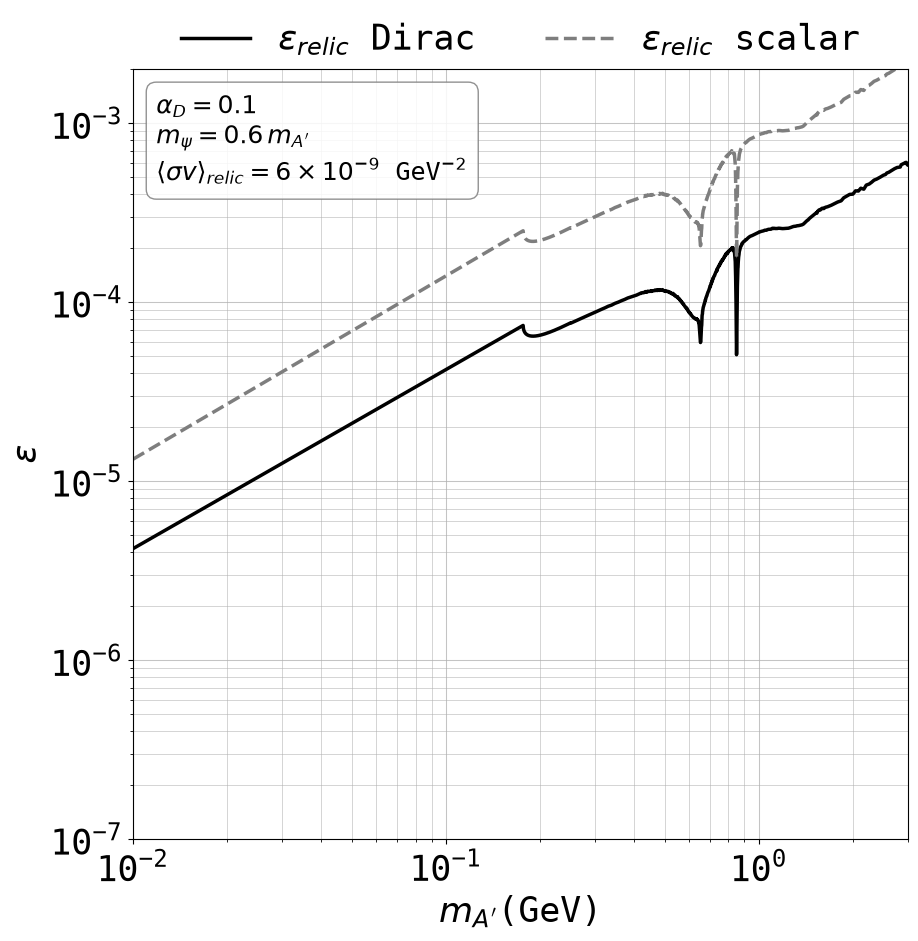

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


#plt.plot(ma, eps_approx_0_dirac, color = 'blue', linewidth = 2.5, label = r"$\varepsilon_{relic}$ low effort 1")
plt.plot(ma, eps_approx_1_dirac, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Dirac")

## The scalar line for comparison. The gap between the two is the sqrt(xf)
## of the p-wave suppression, not a change of parameters: alphaD, the mass
## ratio and the relic cross section are identical on both curves.
plt.plot(ma, eps_approx_1, color = '#7e7e7e', linewidth = 2.5,
         linestyle = '--', label = r"$\varepsilon_{relic}$ scalar")

## Split the target into mantissa and exponent rather than printing it with
## %g, which would render 5e-09 verbatim in the middle of the maths.
sv_mant, sv_exp = f"{sigmav_relic:.0e}".split("e")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\psi = 0.6\, m_{A'}$",
                   r"$\langle \sigma v \rangle_{relic} = %s \times 10^{%d}$ GeV$^{-2}$"
                   % (sv_mant, int(sv_exp))]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_dirac_0.pdf", bbox_inches='tight')
plt.show()

### Solving Boltzmann's equation

Nothing changes from the previous case, just annihilation cross section:

In [ ]:
### Boltzmann equation for the Dirac case.

# H, s and Yeq are unchanged: they describe the bath and the equilibrium
# abundance, neither of which knows the spin of the dark matter. Only the
# cross section and the internal dof differ, so this is dYdx with
# sigmavreldirac in place of sigmavrel.

def dYdxdirac(x, Y, g, vare, ma, alpha, alphaD, mpsi):
    """Dirac DM, <sigma v> from the velocity expansion."""
    return dYdxcore(x, Y, g, mpsi,
                    sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x))

# 2 spin states x (psi, psibar). The complex scalar is counted the same way
# and uses 2, so the two models are normalised alike and the lines compare
# directly.
GDIRAC = 4

def omega_of_dirac(ma, vare, alphaD, mchi_over_ma=0.6,
                   xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point for Dirac DM.

    Deliberately the same signature as omega_of, so scan_relic_line takes
    either one through its omega_fun argument.
    """
    mpsi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxdirac(x, Y, GDIRAC, vare, ma, alpha, alphaD, mpsi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, GDIRAC, mpsi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mpsi, sol.y[0][-1])

# The Newton step in refine_eps uses LOGSLOPE, which was measured on the
# scalar model. Check that it still describes this one rather than assuming.
_v1, _v2 = 1e-5, 1e-4
print("d log Omega / d log vare, Dirac, at alphaD = 0.1:")
for _ma in [0.01, 0.1, 1.0, 3.0]:
    _o1, _o2 = omega_of_dirac(_ma, _v1, 0.1), omega_of_dirac(_ma, _v2, 0.1)
    print(f"  ma = {_ma:5g} GeV: {np.log(_o2/_o1)/np.log(_v2/_v1):6.2f}"
          f"   (LOGSLOPE = {LOGSLOPE})")


d log Omega / d log vare, Dirac, at alphaD = 0.1:
  ma =  0.01 GeV:  -1.88   (LOGSLOPE = -1.8)
  ma =   0.1 GeV:  -1.88   (LOGSLOPE = -1.8)
  ma =     1 GeV:  -1.85   (LOGSLOPE = -1.8)
  ma =     3 GeV:  -1.82   (LOGSLOPE = -1.8)


In [ ]:
### Running the scan, same alphaD and mass ratio as the closed form above.

# The window starts a decade lower than the scalar scans: s-wave annihilation
# reaches the relic cross section at a smaller coupling, so the whole line
# sits around 5x below the scalar one.

ma_scan_dirac = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo_dirac, vare_hi_dirac = 1e-6, 2e-3

eps_relic_dirac, scan_info_dirac = scan_relic_line(
    ma_scan_dirac, vare_lo_dirac, vare_hi_dirac,
    alphaD=0.1, mchi_over_ma=0.6, omega_fun=omega_of_dirac)


alphaD = 0.1, mchi/ma = 0.6, Omega target = 0.265
solved 100 of 100 masses in 163 ODE integrations (1.6 per solved mass)
  solved range ma = 0.01 to 3 GeV


In [ ]:
### Closed form against Boltzmann, on the masses the scan actually solved.

ok_dirac = np.isfinite(eps_relic_dirac)
eps_closed_on_scan = eps_approx1_dirac(ma_scan_dirac[ok_dirac], alpha, 0.1,
                                       0.6*ma_scan_dirac[ok_dirac])
ratio_dirac = eps_closed_on_scan/eps_relic_dirac[ok_dirac]

print(f"closed form / Boltzmann over {ok_dirac.sum()} solved masses:"
      f" {ratio_dirac.min():.3f} to {ratio_dirac.max():.3f}"
      f" (median {np.median(ratio_dirac):.3f})")

# Confirm the returned epsilons really do reproduce the target, since the
# scan stops on a tolerance in log Omega rather than in eps.
_check = np.linspace(0, ok_dirac.sum() - 1, 5, dtype=int)
print("spot check, Omega at the returned eps:")
for j in _check:
    _ma = ma_scan_dirac[ok_dirac][j]
    _ep = eps_relic_dirac[ok_dirac][j]
    print(f"  ma = {_ma:7.4f} GeV, eps = {_ep:.4e} ->"
          f" Omega = {omega_of_dirac(_ma, _ep, 0.1):.4f}"
          f"  (target {scan_info_dirac['target']})")


closed form / Boltzmann over 100 solved masses: 0.851 to 0.921 (median 0.885)
spot check, Omega at the returned eps:
  ma =  0.0100 GeV, eps = 4.6155e-06 -> Omega = 0.2654  (target 0.265)
  ma =  0.0399 GeV, eps = 1.8397e-05 -> Omega = 0.2641  (target 0.265)
  ma =  0.1683 GeV, eps = 8.0284e-05 -> Omega = 0.2646  (target 0.265)
  ma =  0.7105 GeV, eps = 1.5357e-04 -> Omega = 0.2628  (target 0.265)
  ma =  3.0000 GeV, eps = 6.4519e-04 -> Omega = 0.2652  (target 0.265)


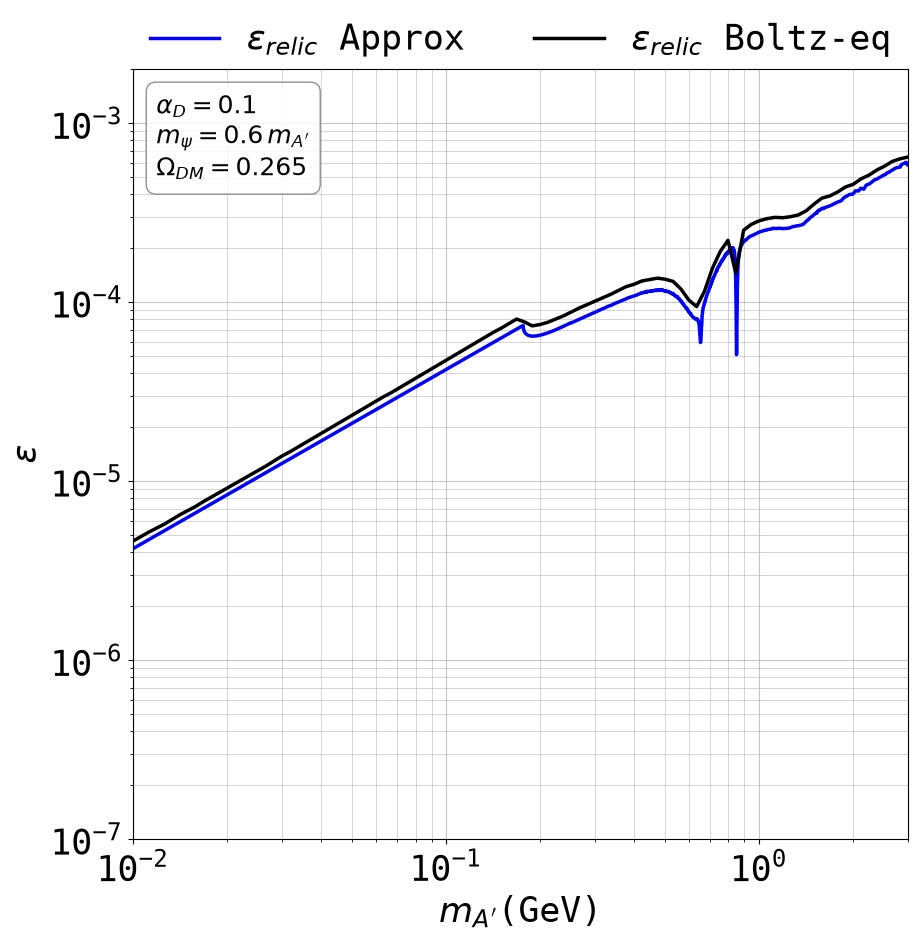

In [ ]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


plt.plot(ma, eps_approx_1_dirac, color = 'blue', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Approx")

plt.plot(ma_scan_dirac, eps_relic_dirac, color = 'black', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over, read back
## out of the scan info dict so the annotation cannot drift away from what
## was actually run.

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % scan_info_dirac["alphaD"],
                   r"$m_\psi = %g\, m_{A'}$" % scan_info_dirac["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info_dirac["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_dirac_scan_0.pdf", bbox_inches='tight')
plt.show()
